# Módulo 2: ACP y Análisis de Clustering
## AmericasBarometer Costa Rica 2023

**Autor:** Stiven Herrera Bonilla  

## Objetivo

Identificar perfiles de ciudadanía política en Costa Rica 2023 mediante
un enfoque inductivo de machine learning no supervisado (ACP + K-means),
y comparar los resultados con los siete perfiles del informe oficial
LAPOP 2023 (Alfaro, 2024), construidos con Fuzzy Sets.

## Pregunta analítica

¿Un enfoque inductivo basado en K-means llega a perfiles similares
a los obtenidos mediante el enfoque deductivo de Fuzzy Sets?

## Variables utilizadas

**Índice de apoyo al sistema** (escala 1-7):
- b1: Tribunales garantizan juicio justo
- b2: Respeto por instituciones políticas
- b3: Derechos básicos protegidos
- b4: Orgullo de vivir bajo el sistema político
- b6: Se debe apoyar al sistema político

**Índice de tolerancia política** (escala 1-10):
- d1: Derecho a votar de críticos del sistema
- d2: Derecho a manifestarse de críticos
- d3: Derecho a postularse a cargos de críticos
- d4: Derecho a dar discursos en TV de críticos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Cargar dataset
df = pd.read_stata('/Users/stevenherrerabonilla/Documents/Date_Analyst_Portafolio/AmericasBarometer 2023 /CRI_2023_LAPOP_AmericasBarometer_v1.0_w.dta',
                   convert_categoricals=False)

# Recrear df_trabajo con las variables clave
variables_clave = [
    'idnum', 'wt', 'estratopri', 'ur',
    'q1tc_r', 'q2', 'edre', 'q10inc',
    'etid', 'q3cn', 'q5b',
    'l1n', 'pol1', 'vb10', 'm1', 'gi0n',
    'b1', 'b2', 'b3', 'b4', 'b6',
    'b13', 'b18', 'b21', 'b31', 'b21a', 'b47a',
    'd1', 'd2', 'd3', 'd4',
    'd5', 'd6', 'vb50', 'ros4',
    'pn4', 'ing4',
    'aoj11', 'exc7new', 'vic1ext'
]

df_trabajo = df[variables_clave].copy()

df_trabajo = df_trabajo.rename(columns={
    'q1tc_r': 'genero',
    'q2':     'edad',
    'edre':   'educacion',
    'q10inc': 'ingreso',
    'q3cn':   'religion',
    'q5b':    'importancia_religion',
    'l1n':    'ideologia',
    'gi0n':   'consume_noticias',
    'pol1':   'interes_politico',
    'vb10':   'simpatia_partido',
    'm1':     'eval_presidente',
    'vic1ext':'victima_delito',
    'aoj11':  'inseguridad',
    'exc7new':'corrupcion_politicos',
    'etid':   'etnia',
    'ur':     'zona'
})

print(f"Dataset cargado: {df_trabajo.shape}")

Dataset cargado: (1527, 40)


In [3]:
# Variables del análisis
apoyo_vars = ['b1', 'b2', 'b3', 'b4', 'b6']
tolerancia_vars = ['d1', 'd2', 'd3', 'd4']
todas_vars = apoyo_vars + tolerancia_vars

# Crear subset solo con estas variables, eliminando faltantes
df_cluster = df_trabajo[todas_vars].dropna()

print(f"Dataset original:        {df_trabajo.shape[0]} personas")
print(f"Dataset para clustering: {df_cluster.shape[0]} personas")
print(f"Casos excluidos:         {df_trabajo.shape[0] - df_cluster.shape[0]}")
print(f"\nEstadísticas descriptivas:")
print(df_cluster.describe().round(2))

Dataset original:        1527 personas
Dataset para clustering: 1464 personas
Casos excluidos:         63

Estadísticas descriptivas:
            b1       b2       b3       b4       b6       d1       d2       d3  \
count  1464.00  1464.00  1464.00  1464.00  1464.00  1464.00  1464.00  1464.00   
mean      3.96     5.52     4.24     5.27     5.47     6.74     7.22     5.21   
std       1.56     1.63     1.64     1.62     1.53     2.60     2.58     2.87   
min       1.00     1.00     1.00     1.00     1.00     1.00     1.00     1.00   
25%       3.00     5.00     3.00     4.00     5.00     5.00     5.00     3.00   
50%       4.00     6.00     4.00     6.00     6.00     7.00     8.00     5.00   
75%       5.00     7.00     5.00     7.00     7.00     9.00    10.00     7.00   
max       7.00     7.00     7.00     7.00     7.00    10.00    10.00    10.00   

            d4  
count  1464.00  
mean      5.57  
std       2.91  
min       1.00  
25%       3.00  
50%       5.00  
75%       8.00  


In [4]:
# Estandarizar todas las variables a media 0 y desviación estándar 1
# Esto elimina el efecto de las escalas diferentes (1-7 vs 1-10)
scaler = StandardScaler()
df_escalado = scaler.fit_transform(df_cluster)

# Convertir a DataFrame para mantener nombres de columnas
df_escalado = pd.DataFrame(df_escalado, 
                           columns=todas_vars,
                           index=df_cluster.index)

print("Variables estandarizadas:")
print(df_escalado.describe().round(2))

Variables estandarizadas:
            b1       b2       b3       b4       b6       d1       d2       d3  \
count  1464.00  1464.00  1464.00  1464.00  1464.00  1464.00  1464.00  1464.00   
mean      0.00    -0.00     0.00     0.00    -0.00    -0.00    -0.00    -0.00   
std       1.00     1.00     1.00     1.00     1.00     1.00     1.00     1.00   
min      -1.91    -2.77    -1.98    -2.64    -2.93    -2.21    -2.41    -1.47   
25%      -0.62    -0.32    -0.76    -0.78    -0.31    -0.67    -0.86    -0.77   
50%       0.02     0.29    -0.15     0.45     0.35     0.10     0.30    -0.07   
75%       0.67     0.91     0.46     1.07     1.00     0.87     1.08     0.62   
max       1.95     0.91     1.68     1.07     1.00     1.25     1.08     1.67   

            d4  
count  1464.00  
mean     -0.00  
std       1.00  
min      -1.57  
25%      -0.89  
50%      -0.20  
75%       0.84  
max       1.52  


In [5]:
# Aplicar ACP con todas las componentes primero
# para ver cuánta varianza explica cada una
pca = PCA()
pca.fit(df_escalado)

# Varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_ * 100
varianza_acumulada = np.cumsum(varianza_explicada)

# Tabla resumen
resumen_pca = pd.DataFrame({
    'Componente': [f'CP{i+1}' for i in range(len(varianza_explicada))],
    'Varianza explicada (%)': varianza_explicada.round(2),
    'Varianza acumulada (%)': varianza_acumulada.round(2),
    'Autovalor': pca.explained_variance_.round(3)
})

print(resumen_pca.to_string(index=False))

Componente  Varianza explicada (%)  Varianza acumulada (%)  Autovalor
       CP1                   33.20                   33.20      2.990
       CP2                   26.11                   59.31      2.352
       CP3                    8.43                   67.74      0.760
       CP4                    7.74                   75.48      0.697
       CP5                    6.73                   82.21      0.606
       CP6                    5.58                   87.78      0.502
       CP7                    5.40                   93.18      0.486
       CP8                    4.22                   97.40      0.380
       CP9                    2.60                  100.00      0.234


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/08_scree_plot.png'

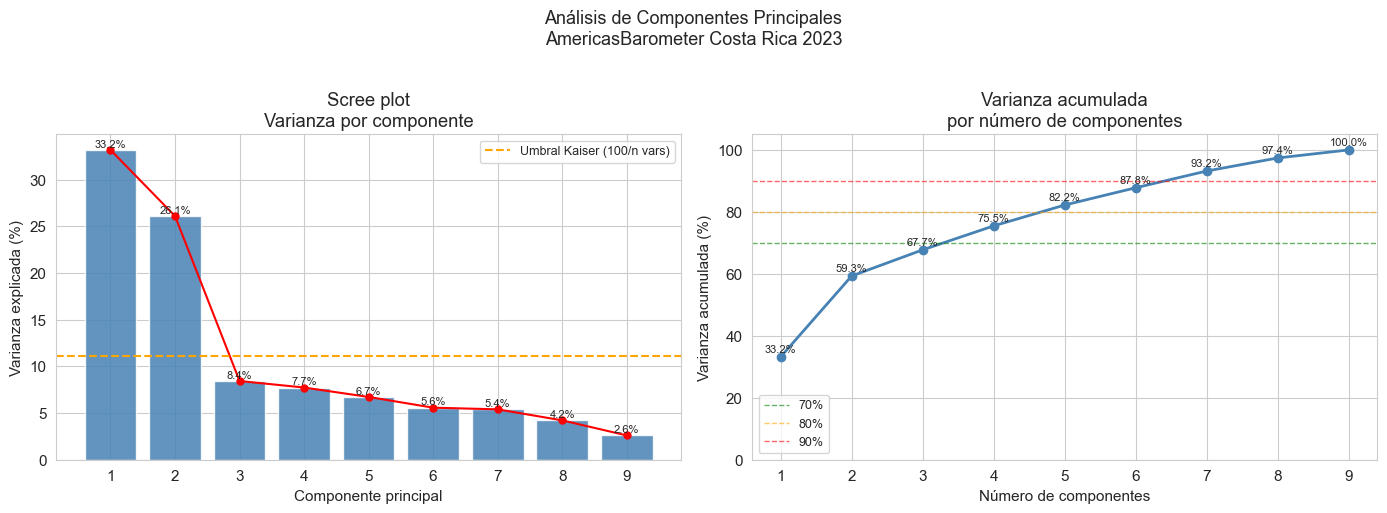

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico izquierdo: varianza por componente ---
axes[0].bar(range(1, len(varianza_explicada) + 1),
            varianza_explicada,
            color='steelblue', alpha=0.85, edgecolor='white')
axes[0].plot(range(1, len(varianza_explicada) + 1),
             varianza_explicada,
             'o-', color='red', linewidth=1.5, markersize=5)

# Línea de referencia autovalor = 1 (regla de Kaiser)
# En datos estandarizados, autovalor=1 corresponde a ~11.1% (100/9 variables)
axes[0].axhline(y=100/9, color='orange', linestyle='--',
                linewidth=1.5, label='Umbral Kaiser (100/n vars)')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Scree plot\nVarianza por componente')
axes[0].set_xticks(range(1, len(varianza_explicada) + 1))
axes[0].legend(fontsize=9)

# Etiquetas
for i, v in enumerate(varianza_explicada):
    axes[0].text(i + 1, v + 0.3, f'{v:.1f}%',
                 ha='center', fontsize=8)

# --- Gráfico derecho: varianza acumulada ---
axes[1].plot(range(1, len(varianza_acumulada) + 1),
             varianza_acumulada,
             'o-', color='steelblue', linewidth=2, markersize=6)

# Líneas de referencia en 70%, 80%, 90%
for umbral, color in [(70, 'green'), (80, 'orange'), (90, 'red')]:
    axes[1].axhline(y=umbral, color=color, linestyle='--',
                    alpha=0.6, linewidth=1,
                    label=f'{umbral}%')
    
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada\npor número de componentes')
axes[1].set_xticks(range(1, len(varianza_acumulada) + 1))
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)

# Etiquetas
for i, v in enumerate(varianza_acumulada):
    axes[1].text(i + 1, v + 1.5, f'{v:.1f}%',
                 ha='center', fontsize=8)

plt.suptitle('Análisis de Componentes Principales\nAmericasBarometer Costa Rica 2023',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/08_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Paso 1: Análisis de Componentes Principales (ACP)

### ¿Por qué aplicamos ACP antes del clustering?

Las 9 variables del análisis (5 de apoyo al sistema y 4 de tolerancia)
están correlacionadas entre sí, como confirmó el heatmap del Módulo 1.
Meter variables correlacionadas directamente en K-means distorsiona los
resultados porque el algoritmo contaría varias veces la misma información.

El ACP resuelve este problema transformando las 9 variables originales
en componentes independientes entre sí, ordenados de mayor a menor
varianza explicada.

### Resultados del ACP

La tabla de varianza explicada muestra que:
- **CP1** explica el 33.2% de la varianza (autovalor=2.99)
- **CP2** explica el 26.1% adicional (autovalor=2.35)
- **Juntos explican el 59.3%** de toda la información

Solo CP1 y CP2 superan el umbral de Kaiser (autovalor > 1), lo que
indica que dos componentes son suficientes para resumir la estructura
de los datos. Esto coincide con las dos dimensiones teóricas del
análisis: apoyo al sistema y tolerancia política.

### Siguiente paso: cargas de los componentes

Para confirmar que CP1 y CP2 corresponden efectivamente a esas dos
dimensiones teóricas, analizamos qué variables contribuyen más a
cada componente.

In [7]:
# Calcular cargas de los dos primeros componentes
pca_2 = PCA(n_components=2)
pca_2.fit(df_escalado)

# Matriz de cargas
cargas = pd.DataFrame(
    pca_2.components_.T,
    index=todas_vars,
    columns=['CP1', 'CP2']
)

# Etiquetas descriptivas para cada variable
etiquetas = {
    'b1': 'Tribunales (b1)',
    'b2': 'Inst. políticas (b2)',
    'b3': 'Derechos (b3)',
    'b4': 'Orgullo sistema (b4)',
    'b6': 'Apoyar sistema (b6)',
    'd1': 'Votar críticos (d1)',
    'd2': 'Manifestarse (d2)',
    'd3': 'Postularse (d3)',
    'd4': 'Discurso TV (d4)'
}

cargas.index = [etiquetas[v] for v in cargas.index]
print("Matriz de cargas de los componentes:")
print(cargas.round(3))

Matriz de cargas de los componentes:
                        CP1    CP2
Tribunales (b1)       0.346 -0.182
Inst. políticas (b2)  0.300 -0.321
Derechos (b3)         0.393 -0.266
Orgullo sistema (b4)  0.379 -0.295
Apoyar sistema (b6)   0.373 -0.262
Votar críticos (d1)   0.282  0.354
Manifestarse (d2)     0.271  0.374
Postularse (d3)       0.313  0.433
Discurso TV (d4)      0.318  0.429


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/09_cargas_pca.png'

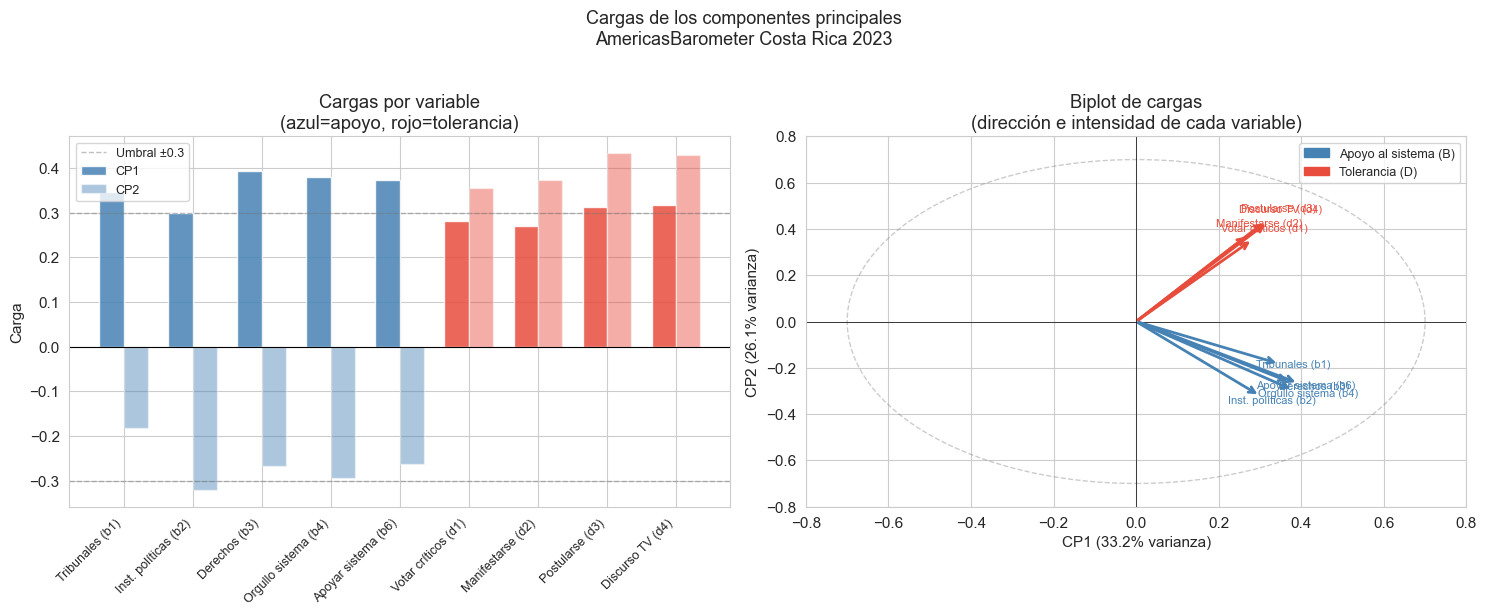

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Gráfico izquierdo: cargas como barras ---
colores_vars = ['steelblue'] * 5 + ['#e74c3c'] * 4  # azul=apoyo, rojo=tolerancia

x = np.arange(len(cargas))
ancho = 0.35

barras1 = axes[0].bar(x - ancho/2, cargas['CP1'],
                      ancho, label='CP1', 
                      color=colores_vars, alpha=0.85)
barras2 = axes[0].bar(x + ancho/2, cargas['CP2'],
                      ancho, label='CP2',
                      color=colores_vars, alpha=0.45)

axes[0].set_xticks(x)
axes[0].set_xticklabels(cargas.index, rotation=45, ha='right', fontsize=9)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(0.3, color='gray', linestyle='--', 
                alpha=0.5, linewidth=1, label='Umbral ±0.3')
axes[0].axhline(-0.3, color='gray', linestyle='--', alpha=0.5, linewidth=1)
axes[0].set_ylabel('Carga')
axes[0].set_title('Cargas por variable\n(azul=apoyo, rojo=tolerancia)')
axes[0].legend(fontsize=9)

# --- Gráfico derecho: biplot ---
for i, var in enumerate(cargas.index):
    cp1 = cargas['CP1'].iloc[i]
    cp2 = cargas['CP2'].iloc[i]
    color = 'steelblue' if i < 5 else '#e74c3c'
    
    axes[1].annotate('', xy=(cp1, cp2), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', 
                                    color=color, lw=2))
    axes[1].text(cp1 * 1.1, cp2 * 1.1, var,
                 fontsize=8, color=color, ha='center')

axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlabel(f'CP1 ({varianza_explicada[0]:.1f}% varianza)')
axes[1].set_ylabel(f'CP2 ({varianza_explicada[1]:.1f}% varianza)')
axes[1].set_title('Biplot de cargas\n(dirección e intensidad de cada variable)')
axes[1].set_xlim(-0.8, 0.8)
axes[1].set_ylim(-0.8, 0.8)

# Círculo de referencia
circulo = plt.Circle((0, 0), 0.7, fill=False, 
                      color='gray', linestyle='--', alpha=0.4)
axes[1].add_patch(circulo)

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [Patch(color='steelblue', label='Apoyo al sistema (B)'),
           Patch(color='#e74c3c', label='Tolerancia (D)')]
axes[1].legend(handles=leyenda, fontsize=9)

plt.suptitle('Cargas de los componentes principales\nAmericasBarometer Costa Rica 2023',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/09_cargas_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación de las cargas

**CP1 — Actitud general pro-sistema:**
Todas las variables cargan positivamente (0.27-0.39), con las variables
de apoyo al sistema (B) dominando ligeramente. CP1 representa un eje
general de respaldo al sistema político: puntuaciones altas indican
personas con alta confianza institucional y tolerancia simultáneas.

**CP2 — Tensión apoyo institucional vs tolerancia:**
Las variables de apoyo (B) cargan negativamente (-0.18 a -0.32) y las
de tolerancia (D) cargan positivamente (0.35-0.43). CP2 captura la
tensión entre ambas dimensiones: personas con puntuaciones altas son
tolerantes pero menos comprometidas con las instituciones, y viceversa.

Esta estructura de dos componentes confirma las dos dimensiones teóricas
del análisis de Alfaro Redondo (2024): apoyo al sistema y tolerancia
política. El enfoque inductivo (ACP) recupera la misma estructura que
el enfoque deductivo (Fuzzy Sets).

## Paso 2: Clustering con K-means

### ¿Cuántos clusters usar?

K-means requiere definir el número de grupos (K) antes de correr
el análisis. Para determinarlo usamos dos criterios complementarios:

1. **Método del codo:** graficamos la inercia (distancia promedio
   de cada punto a su centro) para K entre 2 y 10. El punto donde
   la curva deja de bajar bruscamente indica el K óptimo.

2. **Coeficiente de silueta:** mide qué tan bien separados están
   los clusters. Valores cercanos a 1 indican clusters bien definidos,
   valores cercanos a 0 indican clusters solapados.

Adicionalmente, el informe oficial LAPOP 2023 identifica 7 perfiles
usando Fuzzy Sets. Exploraremos si K-means converge hacia un número
similar o diferente.

In [9]:
# Proyectar datos en los dos componentes principales
coordenadas_pca = pca_2.transform(df_escalado)

df_pca = pd.DataFrame(
    coordenadas_pca,
    columns=['CP1', 'CP2'],
    index=df_cluster.index
)

print(f"Datos proyectados: {df_pca.shape}")
print(df_pca.describe().round(3))

Datos proyectados: (1464, 2)
            CP1       CP2
count  1464.000  1464.000
mean     -0.000     0.000
std       1.729     1.534
min      -6.600    -4.525
25%      -1.030    -1.011
50%       0.048    -0.058
75%       1.222     0.955
max       4.044     5.533


In [10]:
# Calcular inercia y silueta para K entre 2 y 10
inercias = []
siluetas = []
rango_k = range(2, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(df_pca, kmeans.labels_))
    print(f"K={k}: inercia={kmeans.inertia_:.1f}, silueta={silhouette_score(df_pca, kmeans.labels_):.3f}")

K=2: inercia=5059.9, silueta=0.331
K=3: inercia=3366.5, silueta=0.354
K=4: inercia=2630.7, silueta=0.348
K=5: inercia=2162.1, silueta=0.342
K=6: inercia=1811.3, silueta=0.340
K=7: inercia=1547.9, silueta=0.338
K=8: inercia=1382.5, silueta=0.325
K=9: inercia=1221.2, silueta=0.337
K=10: inercia=1100.4, silueta=0.340


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/10_metodo_codo.png'

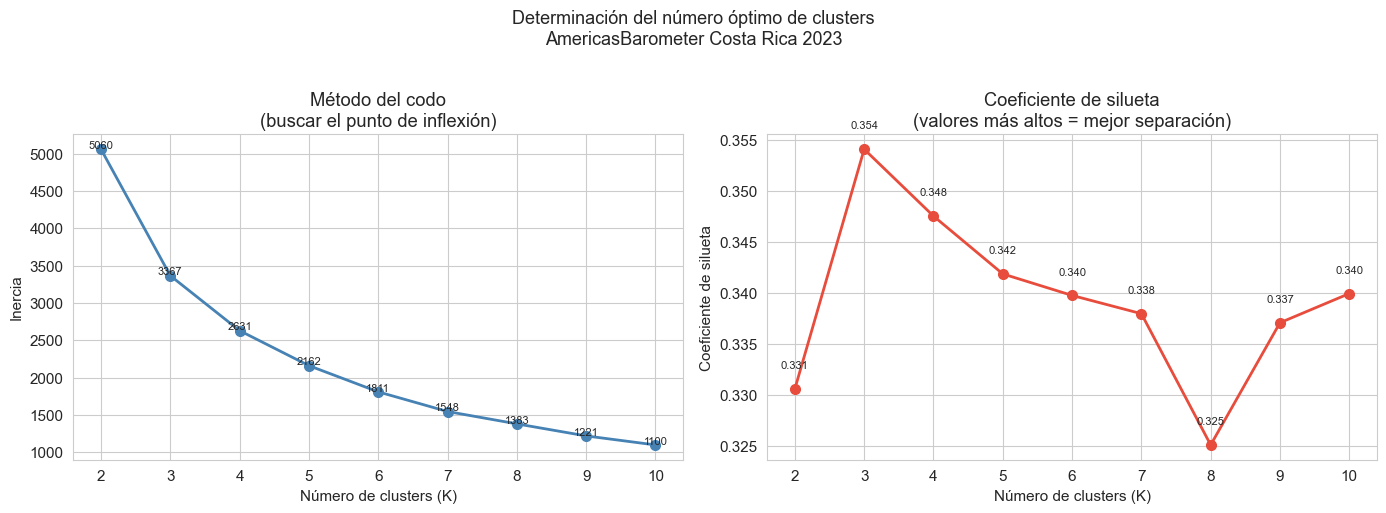

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico izquierdo: método del codo ---
axes[0].plot(rango_k, inercias, 'o-',
             color='steelblue', linewidth=2, markersize=7)

axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo\n(buscar el punto de inflexión)')
axes[0].set_xticks(list(rango_k))

# Etiquetas
for k, inercia in zip(rango_k, inercias):
    axes[0].text(k, inercia + 10, f'{inercia:.0f}',
                 ha='center', fontsize=8)

# --- Gráfico derecho: coeficiente de silueta ---
axes[1].plot(rango_k, siluetas, 'o-',
             color='#e74c3c', linewidth=2, markersize=7)

axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Coeficiente de silueta')
axes[1].set_title('Coeficiente de silueta\n(valores más altos = mejor separación)')
axes[1].set_xticks(list(rango_k))

# Etiquetas
for k, sil in zip(rango_k, siluetas):
    axes[1].text(k, sil + 0.002, f'{sil:.3f}',
                 ha='center', fontsize=8)

plt.suptitle('Determinación del número óptimo de clusters\nAmericasBarometer Costa Rica 2023',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/10_metodo_codo.png', dpi=150, bbox_inches='tight')
plt.show()

### Selección del número de clusters

Los resultados del método del codo y el coeficiente de silueta sugieren:

| K | Inercia | Silueta | Evaluación |
|---|---------|---------|------------|
| 2 | 5059.9 | 0.331 | Demasiado general |
| 3 | 3366.5 | **0.354** | Óptimo estadístico |
| 4 | 2630.7 | 0.348 | Casi igual silueta, más granularidad |
| 5 | 2162.1 | 0.342 | Aceptable |
| 6+ | - | <0.341 | Silueta decreciente |

**Decisión adoptada: K=4**

Aunque K=3 tiene la silueta marginalmente más alta (0.354 vs 0.348),
la diferencia es mínima (0.006). Se adopta K=4 porque:

1. La caída de inercia entre K=3 y K=4 sigue siendo considerable (736 puntos)
2. Cuatro grupos permiten una narrativa política más rica
3. Facilita la comparación con los perfiles del informe oficial

Esta decisión sigue la práctica estándar en ciencias sociales de
balancear criterios estadísticos con interpretabilidad sustantiva.

## Paso 3: Aplicación de K-means con K=4

Con el número óptimo de clusters definido, aplicamos K-means
sobre las dos dimensiones del ACP. El resultado es la asignación
de cada persona entrevistada a uno de cuatro perfiles de
ciudadanía política.

In [12]:
# Aplicar K-means con K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_pca)

# Asignar etiquetas al dataframe
df_pca['cluster'] = kmeans.labels_

# Distribución de clusters
conteo = df_pca['cluster'].value_counts().sort_index()
pct = (conteo / len(df_pca) * 100).round(1)

resumen = pd.DataFrame({
    'N': conteo,
    'Porcentaje': pct
})

print("Distribución de clusters:")
print(resumen)
print(f"\nCoeficiente de silueta final: {silhouette_score(df_pca[['CP1','CP2']], kmeans.labels_):.3f}")

Distribución de clusters:
           N  Porcentaje
cluster                 
0        211        14.4
1        414        28.3
2        540        36.9
3        299        20.4

Coeficiente de silueta final: 0.348


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/11_clusters_pca.png'

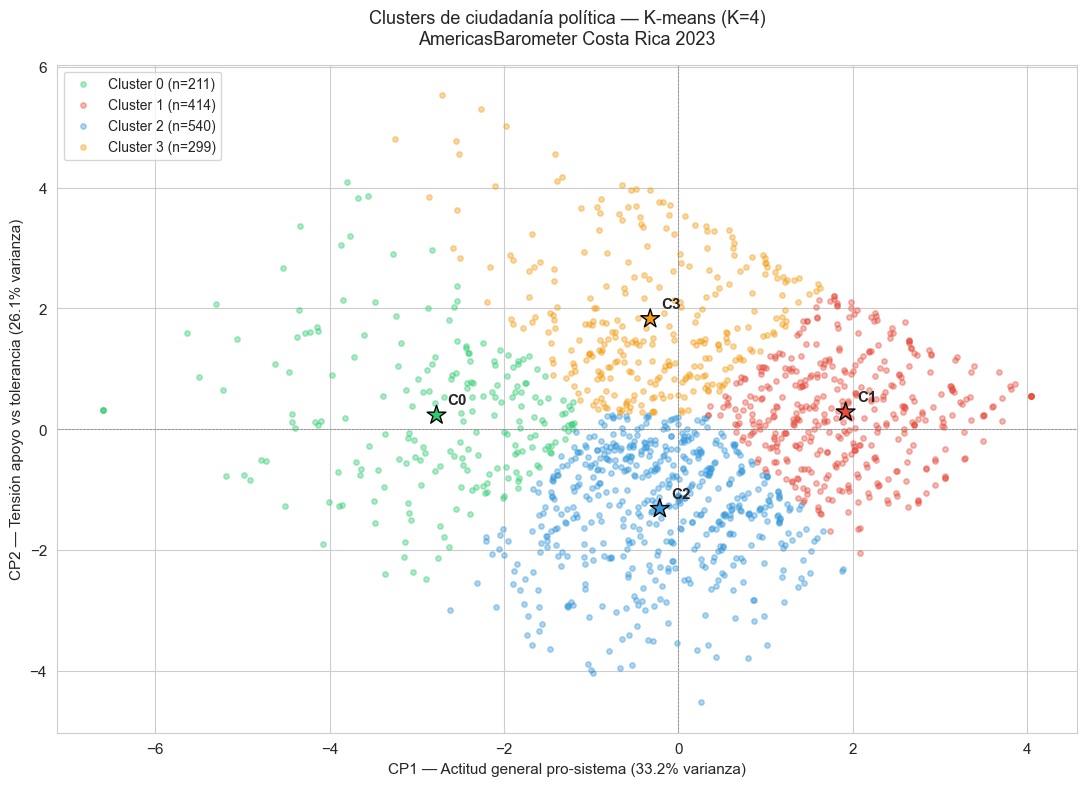

In [13]:
colores_cluster = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
nombres_provisionales = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

fig, ax = plt.subplots(figsize=(11, 8))

for i in range(4):
    mask = df_pca['cluster'] == i
    ax.scatter(df_pca.loc[mask, 'CP1'],
               df_pca.loc[mask, 'CP2'],
               c=colores_cluster[i],
               label=f'Cluster {i} (n={mask.sum()})',
               alpha=0.4, s=15)

# Centroides
centroides = kmeans.cluster_centers_
ax.scatter(centroides[:, 0], centroides[:, 1],
           c=colores_cluster, s=200,
           marker='*', edgecolors='black',
           linewidth=1, zorder=5, label='_nolegend_')

# Etiquetas de centroides
for i, (x, y) in enumerate(centroides):
    ax.annotate(f'C{i}', (x, y),
                textcoords='offset points',
                xytext=(8, 8), fontsize=11,
                fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'CP1 — Actitud general pro-sistema ({varianza_explicada[0]:.1f}% varianza)',
              fontsize=11)
ax.set_ylabel(f'CP2 — Tensión apoyo vs tolerancia ({varianza_explicada[1]:.1f}% varianza)',
              fontsize=11)
ax.set_title('Clusters de ciudadanía política — K-means (K=4)\nAmericasBarometer Costa Rica 2023',
             fontsize=13, pad=15)
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/11_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Perfiles actitudinales por cluster
vars_acp = ['b1', 'b2', 'b3', 'b4', 'b6', 'd1', 'd2', 'd3', 'd4']

# Agregar cluster al dataframe de trabajo
df_cluster['cluster'] = kmeans.labels_

perfil = df_cluster.groupby('cluster')[vars_acp].mean().round(2)
print("=== Promedios por cluster ===")
print(perfil.T)

=== Promedios por cluster ===
cluster     0     1     2     3
b1       2.58  4.95  4.16  3.22
b2       4.03  6.32  6.11  4.40
b3       2.42  5.42  4.65  3.17
b4       3.35  6.27  5.81  4.25
b6       3.72  6.40  5.92  4.61
d1       4.87  8.29  5.49  8.17
d2       5.65  8.77  5.82  8.71
d3       2.95  7.37  3.34  7.19
d4       3.21  7.78  3.66  7.63


In [15]:
# Perfil sociodemográfico por cluster
# Primero agregar variables sociodemográficas al df_cluster
vars_demo = ['genero', 'edad', 'educacion', 'ideologia']

df_cluster_demo = df_cluster.copy()
for var in vars_demo:
    df_cluster_demo[var] = df_trabajo[var]

demo = df_cluster_demo.groupby('cluster')[vars_demo].mean().round(2)
print("=== Perfil sociodemográfico por cluster ===")
print(demo)

=== Perfil sociodemográfico por cluster ===
         genero   edad  educacion  ideologia
cluster                                     
0          1.60  40.98       3.18       4.64
1          1.47  40.50       3.46       5.94
2          1.49  43.09       3.12       5.55
3          1.50  38.32       3.71       5.04


## Interpretación de los clusters

### Nombres asignados

| Cluster | N | % | Nombre | Característica central |
|---------|---|---|--------|----------------------|
| C0 | 211 | 14.4% | Escépticos autoritarios | Bajo apoyo + baja tolerancia |
| C1 | 414 | 28.3% | Demócratas liberales | Alto apoyo + alta tolerancia |
| C2 | 540 | 36.9% | Demócratas iliberales | Alto apoyo + baja tolerancia |
| C3 | 299 | 20.4% | Liberales semidemócratas | Bajo apoyo + alta tolerancia |

### Comparación con el informe oficial LAPOP 2023

El enfoque inductivo (K-means) converge con los perfiles del enfoque
deductivo (Fuzzy Sets) de Alfaro Redondo (2024) en las cuatro
posiciones cuadrantes del espacio apoyo-tolerancia. La principal
diferencia es que K=4 no captura los subtipos intermedios que
Fuzzy Sets sí distingue con mayor granularidad.

**Hallazgo central:** el cluster más numeroso (C2, 36.9%) corresponde
a los "demócratas iliberales": personas que apoyan las instituciones
pero no toleran la disidencia política. Este perfil es el más
preocupante desde una perspectiva de consolidación democrática.

### Perfil sociodemográfico de los clusters

El análisis sociodemográfico revela patrones consistentes con
la literatura comparada:

**Edad:** Los demócratas iliberales (C2) son el cluster de mayor
edad promedio (43 años), mientras que los liberales semidemócratas
(C3) son los más jóvenes (38 años). La tolerancia política tiende
a ser mayor entre generaciones más jóvenes.

**Educación:** C3 tiene el nivel educativo más alto (3.71) y C2
el más bajo (3.12), confirmando la asociación positiva entre
educación y tolerancia política documentada en la literatura.

**Ideología:** C1 (demócratas liberales) se ubica ligeramente
a la derecha del centro (5.94), mientras C0 (escépticos) es
el más cercano al centro-izquierda (4.64). La tolerancia política
no es exclusiva de ningún extremo del espectro ideológico.

**Hallazgo central:** El cluster más numeroso (C2, 36.9%)
combina alto apoyo institucional con baja tolerancia política,
siendo el de mayor edad y menor educación. Este perfil de
"demócrata iLiberal" representa el principal desafío para la
consolidación democrática costarricense.

## Visualizaciones finales de los perfiles

### Gráfico de radar
Comparación de los cuatro clusters en las 9 variables originales.
Permite ver simultáneamente el patrón completo de cada perfil.

### Nota sobre las escalas
Para comparar visualmente las variables B (1-7) y D (1-10) en el
mismo gráfico, normalizamos ambas escalas a un rango de 0 a 1.

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/12_radar_clusters.png'

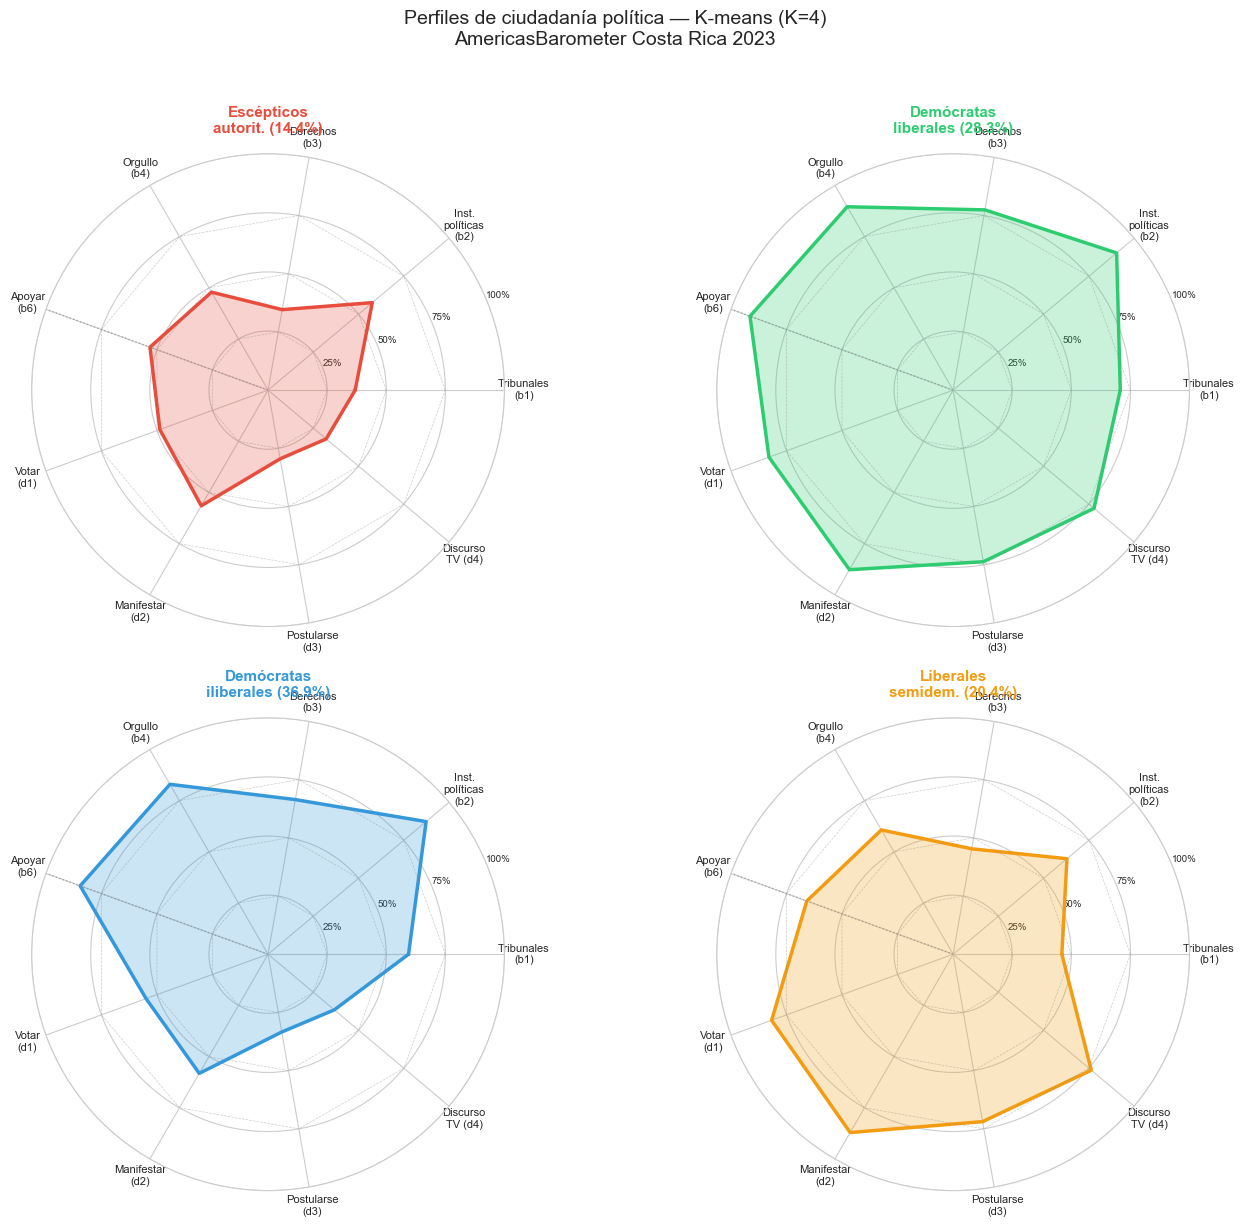

In [16]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Nombres de los clusters
nombres_clusters = {
    0: 'Escépticos\nautorit. (14.4%)',
    1: 'Demócratas\nliberales (28.3%)',
    2: 'Demócratas\niliberales (36.9%)',
    3: 'Liberales\nsemidem. (20.4%)'
}

colores_cluster = {
    0: '#e74c3c',
    1: '#2ecc71', 
    2: '#3498db',
    3: '#f39c12'
}

# Variables y sus escalas máximas para normalizar
vars_radar = ['b1','b2','b3','b4','b6','d1','d2','d3','d4']
etiq_radar = ['Tribunales\n(b1)', 'Inst.\npolíticas\n(b2)', 
              'Derechos\n(b3)', 'Orgullo\n(b4)', 'Apoyar\n(b6)',
              'Votar\n(d1)', 'Manifestar\n(d2)', 
              'Postularse\n(d3)', 'Discurso\nTV (d4)']
maximos = [7, 7, 7, 7, 7, 10, 10, 10, 10]

# Normalizar promedios a escala 0-1
perfil_norm = perfil[vars_radar].copy()
for var, maximo in zip(vars_radar, maximos):
    perfil_norm[var] = perfil_norm[var] / maximo

# Configuración del radar
n_vars = len(vars_radar)
angulos = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angulos += angulos[:1]  # cerrar el polígono

fig, axes = plt.subplots(2, 2, figsize=(14, 12),
                          subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, (cluster_id, ax) in enumerate(zip(range(4), axes)):
    valores = perfil_norm.loc[cluster_id, vars_radar].tolist()
    valores += valores[:1]  # cerrar

    # Área del cluster
    ax.fill(angulos, valores,
            color=colores_cluster[cluster_id], alpha=0.25)
    ax.plot(angulos, valores,
            color=colores_cluster[cluster_id],
            linewidth=2.5)

    # Líneas de referencia
    for nivel in [0.25, 0.50, 0.75]:
        ax.plot(angulos, [nivel] * (n_vars + 1),
                color='gray', linewidth=0.5,
                linestyle='--', alpha=0.4)

    # Etiquetas de variables
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(etiq_radar, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.50, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7)

    # Línea divisoria B vs D
    ax.axvline(angulos[4], color='gray',
               linewidth=1, linestyle=':', alpha=0.6)

    ax.set_title(nombres_clusters[cluster_id],
                 fontsize=11, pad=15,
                 color=colores_cluster[cluster_id],
                 fontweight='bold')

plt.suptitle('Perfiles de ciudadanía política — K-means (K=4)\nAmericasBarometer Costa Rica 2023',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/12_radar_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/13_comparacion_perfiles.png'

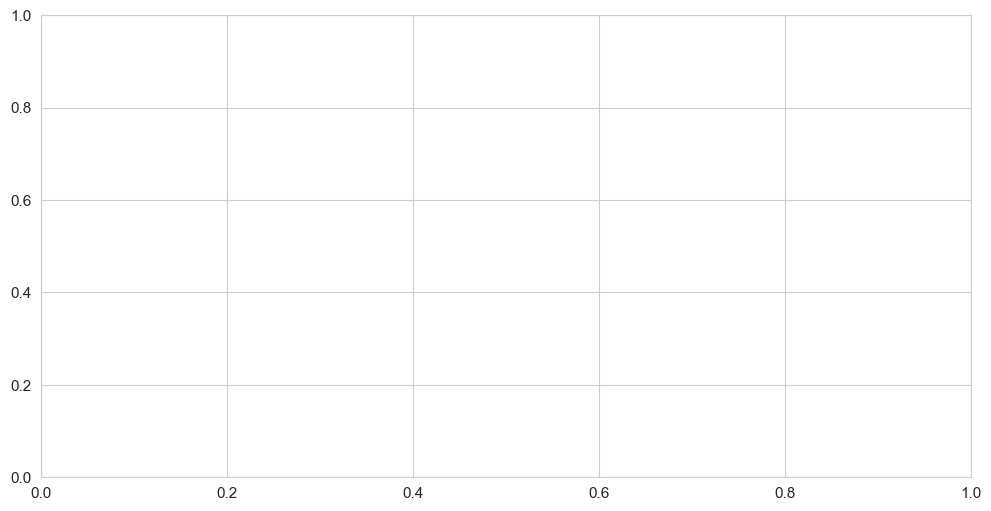

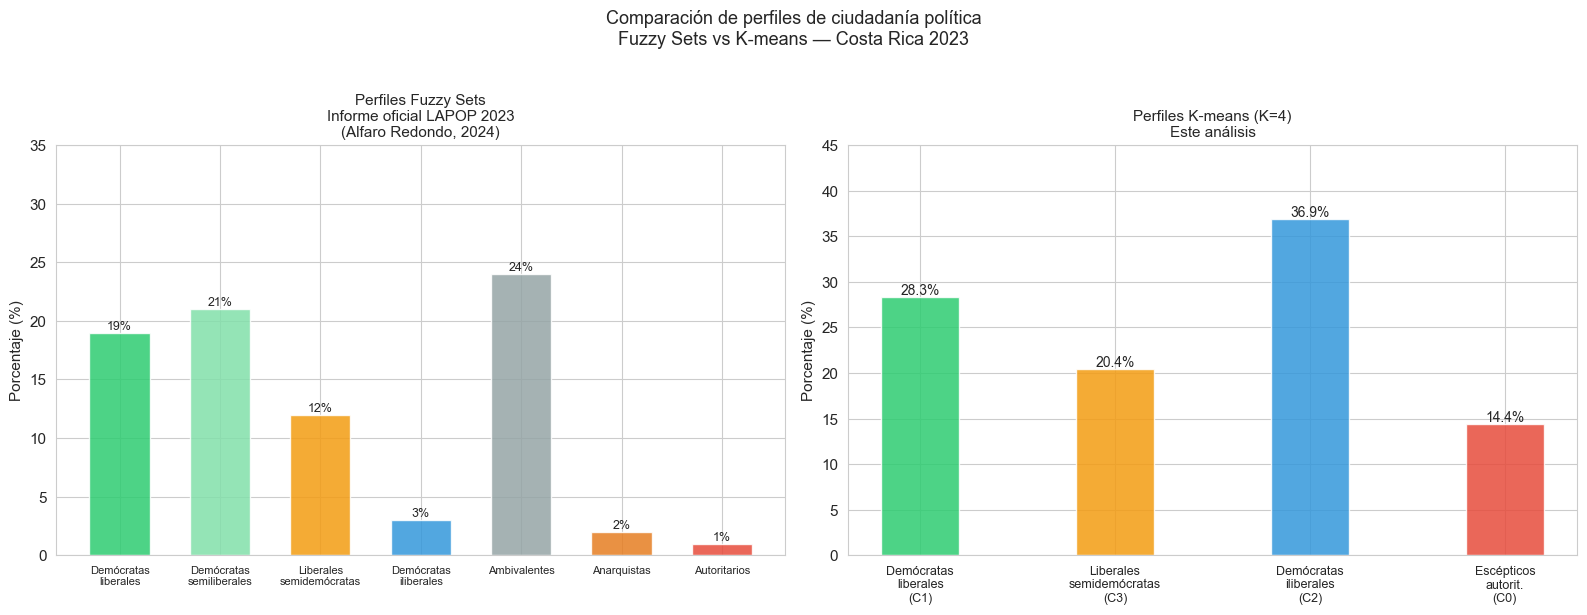

In [17]:
# Comparación de distribuciones: K-means vs informe oficial
fig, ax = plt.subplots(figsize=(12, 6))

# Datos
perfiles_oficial = {
    'Demócratas\nliberales': 19,
    'Demócratas\nsemiliberales': 21,
    'Liberales\nsemidemócratas': 12,
    'Demócratas\niliberales': 3,
    'Ambivalentes': 24,
    'Anarquistas': 2,
    'Autoritarios': 1
}

perfiles_kmeans = {
    'Demócratas\nliberales\n(C1)': 28.3,
    'Liberales\nsemidemócratas\n(C3)': 20.4,
    'Demócratas\niliberales\n(C2)': 36.9,
    'Escépticos\nautorit.\n(C0)': 14.4
}

x1 = np.arange(len(perfiles_oficial))
x2 = np.arange(len(perfiles_kmeans))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Informe oficial
colores_oficial = ['#2ecc71', '#82e0aa', '#f39c12', 
                   '#3498db', '#95a5a6', '#e67e22', '#e74c3c']
barras1 = axes[0].bar(x1, list(perfiles_oficial.values()),
                      color=colores_oficial, alpha=0.85,
                      edgecolor='white', width=0.6)
for barra, val in zip(barras1, perfiles_oficial.values()):
    axes[0].text(barra.get_x() + barra.get_width()/2,
                 barra.get_height() + 0.3,
                 f'{val}%', ha='center', fontsize=9)
axes[0].set_xticks(x1)
axes[0].set_xticklabels(list(perfiles_oficial.keys()), fontsize=8)
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 35)
axes[0].set_title('Perfiles Fuzzy Sets\nInforme oficial LAPOP 2023\n(Alfaro Redondo, 2024)',
                  fontsize=11)

# K-means
colores_kmeans = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c']
barras2 = axes[1].bar(x2, list(perfiles_kmeans.values()),
                      color=colores_kmeans, alpha=0.85,
                      edgecolor='white', width=0.4)
for barra, val in zip(barras2, perfiles_kmeans.values()):
    axes[1].text(barra.get_x() + barra.get_width()/2,
                 barra.get_height() + 0.3,
                 f'{val}%', ha='center', fontsize=10)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(list(perfiles_kmeans.keys()), fontsize=9)
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, 45)
axes[1].set_title('Perfiles K-means (K=4)\nEste análisis',
                  fontsize=11)

plt.suptitle('Comparación de perfiles de ciudadanía política\nFuzzy Sets vs K-means — Costa Rica 2023',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/13_comparacion_perfiles.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusiones del Módulo 2: ACP y Clustering

## 1. Validación metodológica

El ACP aplicado a las 9 variables de apoyo al sistema (B1-B6) y
tolerancia política (D1-D4) identificó dos componentes principales
que explican el 59.3% de la varianza total:

- **CP1** (33.2%): actitud general pro-sistema, con cargas positivas
  en todas las variables
- **CP2** (26.1%): tensión entre apoyo institucional y tolerancia,
  con variables B negativas y variables D positivas

Esta estructura de dos componentes confirma inductivamente las dos
dimensiones teóricas del informe oficial (Alfaro Redondo, 2024),
construidas deductivamente con Fuzzy Sets. El enfoque inductivo
y el deductivo convergen en la misma arquitectura conceptual.

---

## 2. Los cuatro perfiles de ciudadanía política

| Cluster | Nombre | N | % | Apoyo | Tolerancia |
|---------|--------|---|---|-------|------------|
| C1 | Demócratas liberales | 414 | 28.3% | Muy alto | Muy alta |
| C2 | Demócratas iliberales | 540 | 36.9% | Alto | Muy baja |
| C3 | Liberales semidemócratas | 299 | 20.4% | Moderado | Muy alta |
| C0 | Escépticos autoritarios | 211 | 14.4% | Muy bajo | Baja |

---

## 3. Hallazgos principales

**Hallazgo 1 — Mayoría iLiberal:**
El cluster más numeroso (C2, 36.9%) combina alto apoyo institucional
con baja tolerancia política. Más de un tercio de la ciudadanía
sostiene el sistema en términos procedimentales pero restringe
el pluralismo. El sistema se mantiene en legitimidad formal,
no en cultura democrática sustantiva.

**Hallazgo 2 — Minoría democrática genuina:**
Solo el 28.3% (C1) combina alto apoyo institucional con alta
tolerancia. Los demócratas liberales son la minoría más completa
democráticamente pero no la mayoría.

**Hallazgo 3 — Tensión estructural:**
Sumando demócratas iliberales y escépticos autoritarios, más del
51% de la población tiene tolerancia política baja o muy baja.
Esto contrasta directamente con el imaginario excepcionalista
costarricense y conecta con la literatura sobre erosión democrática
(Levitsky y Ziblatt, 2018).

**Hallazgo 4 — Perfil sociodemográfico de la intolerancia:**
Los demócratas iliberales (C2) son el cluster de mayor edad (43
años) y menor educación (3.12). La tolerancia política se asocia
positivamente con juventud y educación, consistente con la
literatura de Pignataro y Treminio (2021) sobre jóvenes y
comportamiento electoral en Costa Rica.

**Hallazgo 5 — Los liberales semidemócratas como perfil inestable:**
El 20.4% (C3) defiende libertades civiles pero desconfía de las
instituciones que deberían garantizarlas. Es una posición
teóricamente inestable: valoran la democracia sustantiva pero
no confían en las instituciones que deberían garantizarla.
Como se confirma en el Módulo 3, este perfil muestra la menor
satisfacción democrática de todos los clusters, incluso por
debajo de los escépticos autoritarios — una insatisfacción
exigente, no nihilista. Este hallazgo es políticamente relevante
en el contexto del populismo de Rodrigo Chaves (2022-2026).

---

## 4. Comparación con el informe oficial

| Perfil Alfaro Redondo | % oficial | Equivalente K-means | % K-means |
|-----------------------|-----------|---------------------|-----------|
| Demócratas liberales | 19% | C1 | 28.3% |
| Demócratas semiliberales | 21% | — | — |
| Liberales semidemócratas | 12% | C3 | 20.4% |
| Demócratas iliberales | 3% | C2 | 36.9% |
| Ambivalentes | 24% | C0 (parcial) | 14.4% |

La principal diferencia es la proporción de demócratas iliberales:
el informe oficial reporta 3% con Fuzzy Sets mientras K-means
identifica 36.9%. Esto refleja una diferencia metodológica
fundamental: Fuzzy Sets usa umbrales estrictos y predefinidos,
mientras K-means agrupa por similitud relativa sin umbrales fijos.
Los "iliberales" de K-means incluyen personas que en Fuzzy Sets
quedarían clasificadas como semiliberales o ambivalentes.

---

## 5. Decisiones metodológicas para el Módulo 3

Los clusters identificados en este módulo se utilizarán en el
Módulo 3 de la siguiente manera:

- **Variable dependiente alternativa:** pertenencia al cluster C1
  (demócratas liberales) codificada como binaria (1=C1, 0=otros)
- **Variable de control:** el cluster asignado se incluirá como
  predictor en el modelo de satisfacción con la democracia (pn4)
  para evaluar si el perfil actitudinal predice la satisfacción
  más allá de las variables sociodemográficas

El Módulo 3 cerrará el proyecto conectando los tres análisis:
EDA → perfiles → predictores de satisfacción democrática.